# Appendix: detector error, eligibility, and observed regression to the mean

This executed notebook reports every simulated condition, selection diagnostics, correction comparisons, and the fixed-cohort sensitivity analysis. These additional analyses were performed during manuscript revision, not prespecified. All counts are simulated.

## Shared participant characteristics and reproducibility

Each of 100,000 potential participants has a 60-day baseline, a 90-day test period, and no treatment effect. A separate 1,080-day realization estimates effective long-term frequency. A simulated month is 30 days throughout. The two realizations share the sampled monthly rate, cluster status and settings, and cycle frequencies and amplitudes. Their random count realizations differ. The long-term diary is not a continuation of the trial diary, and shared cycle parameters do not imply a shared daily intensity trajectory.

At one sample per day, the unchanged CHOCOLATES source cannot represent 12-hour or 24-hour within-day cycles. Its configured weekly component has zero amplitude. Longer cycles, when drawn, remain possible. The daily study therefore does not reproduce the simulator's full within-day rhythmic behavior. Empirical diaries used to develop CHOCOLATES can contain reporting error; treating generated events as latent biological truth is a modeling assumption.

The base seed is 20260813, the nested detection seed is 20260814, and the nested false-alarm seed is 20260815. Lower-sensitivity detections are contained in higher-sensitivity realizations. Higher false-alarm conditions add independent Poisson increments. Every eligibility/correction comparison uses the same latent participants and the same detector realization at that condition. Intervals quantify Monte Carlo sampling uncertainty conditional on this model, not uncertainty about its assumptions or real devices.

## Observations and monthly correction

For participant $i$ and day $d$, let $S_{id}$ be latent seizures, $s$ sensitivity, and $\lambda$ the false-alarm rate in alarms/day:

$$D_{id}\mid S_{id}\sim\operatorname{Binomial}(S_{id},s),\quad F_{id}\sim\operatorname{Poisson}(\lambda),\quad Y_{id}=D_{id}+F_{id}.$$

False alarms are independent of latent counts. Let $Y_{im}$ be the observed total in a 30-day month. Expected-alarm correction gives

$$C_{im}=\max(0,Y_{im}-30\lambda).$$

Before flooring, subtracting the known expectation leaves mean-zero false-alarm error in the unselected population. It does not identify individual alarms. Flooring and selection can change the residual error among selected participants. This correction targets sensitivity-scaled latent counts, but it is not an unbiased estimator after flooring.

## Eligibility and additive thresholds

The main rule uses only the two baseline months:

$$E_i=\mathbf1\{C_{i1}\ge3,\ C_{i2}\ge3,\ (C_{i1}+C_{i2})/2\ge4\}.$$

The additive alternative selects on raw observed counts:

$$E_i^{\mathrm{add}}=\mathbf1\{Y_{i1}\ge3+30\lambda,\ Y_{i2}\ge3+30\lambda,\ (Y_{i1}+Y_{i2})/2\ge4+30\lambda\}.$$

The equivalent two-month total threshold is $8+60\lambda$, retaining the separate monthly minimum. Because each eligible corrected month is at least three, neither is on the zero floor. Subtracting $30\lambda$ from each raw month therefore yields exactly the primary inequalities. Thus $E_i^{\mathrm{add}}=E_i$ for every participant. This is an algebraic identity, not only a simulation result. The notebook verifies mask and outcome equality at all 11 false-alarm rates. Both analyses retain corrected outcome counts. Raising raw thresholds changes how the rule is expressed but does not improve precision or remove random false-alarm error.

## Effective long-term reference and strict endpoint

Let $L_i$ be the integer seizure total in the separate 36-month realization:

$$f_i^*=L_i/36,\qquad r_i=s f_i^*.$$

The effective long-term frequency differs from the sampled rate parameter because the realization includes count variability, clustering, and configured cycles. For mean monthly measured baseline $B_i$ and test frequency $T_i$, observed RTM is

$$R_i=\mathbf1\{B_i>r_i,\quad B_i-r_i>|T_i-r_i|\}.$$

Both comparisons are strict. Equal distances do not count. The canonical grid uses an exact common integer scale for the two-month baseline, three-month test, rational sensitivity, and 36-month reference. Retaining $L_i$ prevents floating-point errors at true ties. Genuinely noninteger inputs outside that grid use a documented relative equality tolerance of $10^{-10}$.

The separate uncorrected-outcome comparison uses its observation-scale reference:

$$r_i^{\mathrm{raw}}=s f_i^*+30\lambda.$$

That comparison uses raw counts for eligibility and outcomes with the original fixed count thresholds. It differs from the additive-threshold analysis, which retains corrected outcomes. Comparing raw false-alarm-contaminated outcomes with $s f_i^*$ would mix count scales and is not done here. Exact oracle removal subtracts realized labeled false alarms and uses the latent-count reference. It is invariant across false-alarm conditions by construction.

The observed-RTM indicator describes trajectories. It does not identify an isolated participant-level RTM Type 3 component or divide overall RTM into additive causal parts.

## Percentage change and denominators

For positive measured baseline:

$$PC_i=100(1-T_i/B_i),\qquad\mathrm{MPC}=\operatorname{median}_{i:E_i=1,\ B_i>0}(PC_i).$$

All main-analysis participants have positive baselines. Fixed-cohort participants can have zero measured baseline after detector performance changes. Their percentage change is undefined, regardless of test count. Tables report the full selected count, zero-baseline count, and positive-baseline MPC denominator. No pseudocount is added. Observed RTM always uses the full selected denominator, including zero-baseline participants, who do not meet its criterion.

MPC intervals are nonparametric binomial-order-statistic 95% intervals. CSVs also contain Wilson intervals for selection and observed RTM. No hypothesis tests or between-condition confidence intervals are reported. Conditions share participants, so pointwise intervals are not independent-comparison intervals.

## Fixed versus reselected cohorts

The primary analysis re-evaluates eligibility at every detector condition. The sensitivity analysis selects participants under perfect detection, $s=1$ and $\lambda=0$, then holds their identities fixed. Both strategies use the same latent histories and condition-specific detector counts. Only the membership rule changes. This compares enrollment designs, not a mediation model or additive causal decomposition.

Fixed-cohort outcomes describe changes in measured trajectories without changing initial enrollment. However, MPC remains conditional on positive measured baseline, and that subset can vary. The selected count is constant, but its MPC denominator need not be. This limits interpretation of low-sensitivity fixed-cohort MPC.

## The 25-day rule

Let $L_i(Z)$ be the longest consecutive zero-day run in the 60-day baseline. The interval sensitivity adds $L_i(Z)\le25$ to monthly criteria. The original daily correction is

$$Z_{id}=\max(0,Y_{id}-\operatorname{round}(\lambda)).$$

NumPy nearest-even rounding subtracts zero from zero through 0.5/day and one from 0.6 through 1.0/day. This discontinuity changes zero-day classification without identifying false alarms. Alternatives use observed days, $Z_{id}=Y_{id}$, or oracle detected-seizure days, $Z_{id}=D_{id}$. Only the interval component changes; monthly outcomes retain expected-alarm correction. Oracle intervals and exact oracle alarm removal are separate diagnostics.

The 30-day months adapt clinical criteria rather than reproducing four-week trial windows exactly. Dropping the interval rule removes the need to assign corrected events to days, but it does not eliminate monthly noise or flooring.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from rtm3_reporting import *
results = load_results(Path('results'))
show_design(results)

Parameter,Value
n_patients_per_condition,100000
baseline_months,2
test_months,3
long_term_frequency_months,36
base_seed,20260813
sensitivity_detection_seed,20260814
false_alarm_seed,20260815


Software,Version
matplotlib,3.11.0
numpy,2.5.0
pandas,3.0.3
platform,macOS-26.7-arm64-arm-64bit
python,3.12.13
scipy,1.18.0


Simulator provenance and shared-patient diagnostics:

{'local_source_sha256': '7c4f1ac426a136b7539ed6ab868164e3af67d2322cb9ed558fe34f5428e3ee9d',
 'previous_source_sha256': '7c4f1ac426a136b7539ed6ab868164e3af67d2322cb9ed558fe34f5428e3ee9d',
 'source_file': 'realSim.py',
 'source_migration': 'The requested upstream file is byte-identical to the previous local file.',
 'upstream_commit': '03fdf198d176028e1a495e109029e45f980ba67e',
 'upstream_repository': 'https://github.com/GoldenholzLab/CHOCOLATE',
 'upstream_source_path': '/Users/dgoldenh/Documents/GitHub/CHOCOLATE/realSim.py',
 'upstream_source_sha256': '7c4f1ac426a136b7539ed6ab868164e3af67d2322cb9ed558fe34f5428e3ee9d'}

{'cycle_phase_handling': 'Independent phases for separate histories; frequency and amplitude arrays are fixed per participant.',
 'long_term_total_sha256': '2a66b529678d29fd1de585ee3bbb015c6d89ac44fd097aca3b2852fc896e0d5f',
 'n_clustered_participants': 49793,
 'n_participants_with_nonzero_daily_cycles': 1229,
 'shared_rate_cluster_status_and_cycle_parameters': True}

## Primary results

Every condition is reported. RTM means the observed trajectory indicator. Positive median percentage change, MPC, indicates apparent improvement without treatment.

In [2]:
show_outcomes(results['primary'])

Condition,Selected n,Selected %,Observed RTM %,MPC %,MPC 95% CI,MPC denominator,Zero baseline n
Sensitivity 10%,2180,2.18,64.40,48.15,45.83 to 50.00,2180,0
Sensitivity 20%,5955,5.96,52.76,37.63,35.80 to 38.89,5955,0
Sensitivity 30%,9824,9.82,48.46,33.33,30.56 to 33.33,9824,0
Sensitivity 40%,13845,13.84,46.63,27.54,26.67 to 28.57,13845,0
Sensitivity 50%,17865,17.87,44.49,25.00,24.64 to 25.93,17865,0
Sensitivity 60%,21790,21.79,42.62,21.21,20.83 to 22.22,21790,0
Sensitivity 70%,25546,25.55,40.92,19.05,18.52 to 20.00,25546,0
Sensitivity 80%,29093,29.09,39.31,16.67,16.67 to 17.73,29093,0
Sensitivity 90%,32350,32.35,38.26,15.56,15.15 to 16.67,32350,0
Sensitivity 100%,35393,35.39,37.21,14.29,13.33 to 14.81,35393,0


## Selection diagnostics

Frequencies are seizures per 30-day month among participants meeting primary criteria.

In [3]:
show_selection(results)

### sensitivity sweep

Condition,Selected n,Selected %,Median sampled rate,Median effective long-term rate,Mean baseline,Mean test,Mean baseline minus reference,Mean test minus reference
Sensitivity 10%,2180,2.18,31.63,39.24,7.53,4.68,2.73,-0.11
Sensitivity 20%,5955,5.96,22.06,26.69,9.47,6.85,2.51,-0.11
Sensitivity 30%,9824,9.82,17.92,21.36,10.83,8.51,2.24,-0.09
Sensitivity 40%,13845,13.84,15.22,17.92,11.83,9.70,2.05,-0.08
Sensitivity 50%,17865,17.87,13.21,15.17,12.60,10.63,1.88,-0.09
Sensitivity 60%,21790,21.79,11.74,13.19,13.30,11.51,1.71,-0.08
Sensitivity 70%,25546,25.55,10.65,11.58,13.97,12.30,1.59,-0.07
Sensitivity 80%,29093,29.09,9.84,10.14,14.63,13.07,1.48,-0.08
Sensitivity 90%,32350,32.35,9.22,9.03,15.29,13.82,1.39,-0.08
Sensitivity 100%,35393,35.39,8.75,8.42,15.97,14.57,1.32,-0.08


### FAR sweep

Condition,Selected n,Selected %,Median sampled rate,Median effective long-term rate,Mean baseline,Mean test,Mean baseline minus reference,Mean test minus reference
FAR 0.0/day,35393,35.39,8.75,8.42,15.97,14.57,1.32,-0.08
FAR 0.1/day,35453,35.45,8.64,8.31,16.07,14.42,1.63,-0.02
FAR 0.2/day,35551,35.55,8.52,8.17,16.11,14.25,1.90,0.04
FAR 0.3/day,35437,35.44,8.40,8.03,16.23,14.15,2.18,0.10
FAR 0.4/day,35512,35.51,8.27,7.86,16.30,14.06,2.43,0.19
FAR 0.5/day,35508,35.51,8.19,7.78,16.42,14.02,2.66,0.27
FAR 0.6/day,35462,35.46,8.08,7.67,16.51,13.97,2.88,0.33
FAR 0.7/day,35372,35.37,8.01,7.58,16.64,13.97,3.08,0.41
FAR 0.8/day,35321,35.32,7.94,7.53,16.77,13.98,3.25,0.46
FAR 0.9/day,35224,35.22,7.85,7.44,16.89,13.97,3.45,0.53


## Fixed and reselected cohorts

The fixed cohort is selected once under perfect detection. MPC applies only to positive-baseline participants; zero baselines are reported separately.

### Reselected at each detector condition

Condition,Selected n,Selected %,Observed RTM %,MPC %,MPC 95% CI,MPC denominator,Zero baseline n
Sensitivity 10%,2180,2.18,64.40,48.15,45.83 to 50.00,2180,0
Sensitivity 20%,5955,5.96,52.76,37.63,35.80 to 38.89,5955,0
Sensitivity 30%,9824,9.82,48.46,33.33,30.56 to 33.33,9824,0
Sensitivity 40%,13845,13.84,46.63,27.54,26.67 to 28.57,13845,0
Sensitivity 50%,17865,17.87,44.49,25.00,24.64 to 25.93,17865,0
Sensitivity 60%,21790,21.79,42.62,21.21,20.83 to 22.22,21790,0
Sensitivity 70%,25546,25.55,40.92,19.05,18.52 to 20.00,25546,0
Sensitivity 80%,29093,29.09,39.31,16.67,16.67 to 17.73,29093,0
Sensitivity 90%,32350,32.35,38.26,15.56,15.15 to 16.67,32350,0
Sensitivity 100%,35393,35.39,37.21,14.29,13.33 to 14.81,35393,0


### Fixed perfect-detector cohort

Condition,Selected n,Selected %,Observed RTM %,MPC %,MPC 95% CI,MPC denominator,Zero baseline n
Sensitivity 10%,35393,35.39,29.33,33.33,33.33 to 33.33,29211,6182
Sensitivity 20%,35393,35.39,31.05,16.67,14.29 to 16.67,33813,1580
Sensitivity 30%,35393,35.39,32.74,12.28,11.11 to 14.29,34980,413
Sensitivity 40%,35393,35.39,33.79,13.48,11.71 to 14.29,35291,102
Sensitivity 50%,35393,35.39,34.55,13.33,11.63 to 14.29,35377,16
Sensitivity 60%,35393,35.39,35.29,13.33,12.00 to 14.07,35390,3
Sensitivity 70%,35393,35.39,35.89,13.33,12.82 to 14.29,35393,0
Sensitivity 80%,35393,35.39,36.36,13.89,13.33 to 14.29,35393,0
Sensitivity 90%,35393,35.39,36.86,13.78,13.33 to 14.29,35393,0
Sensitivity 100%,35393,35.39,37.21,14.29,13.33 to 14.81,35393,0


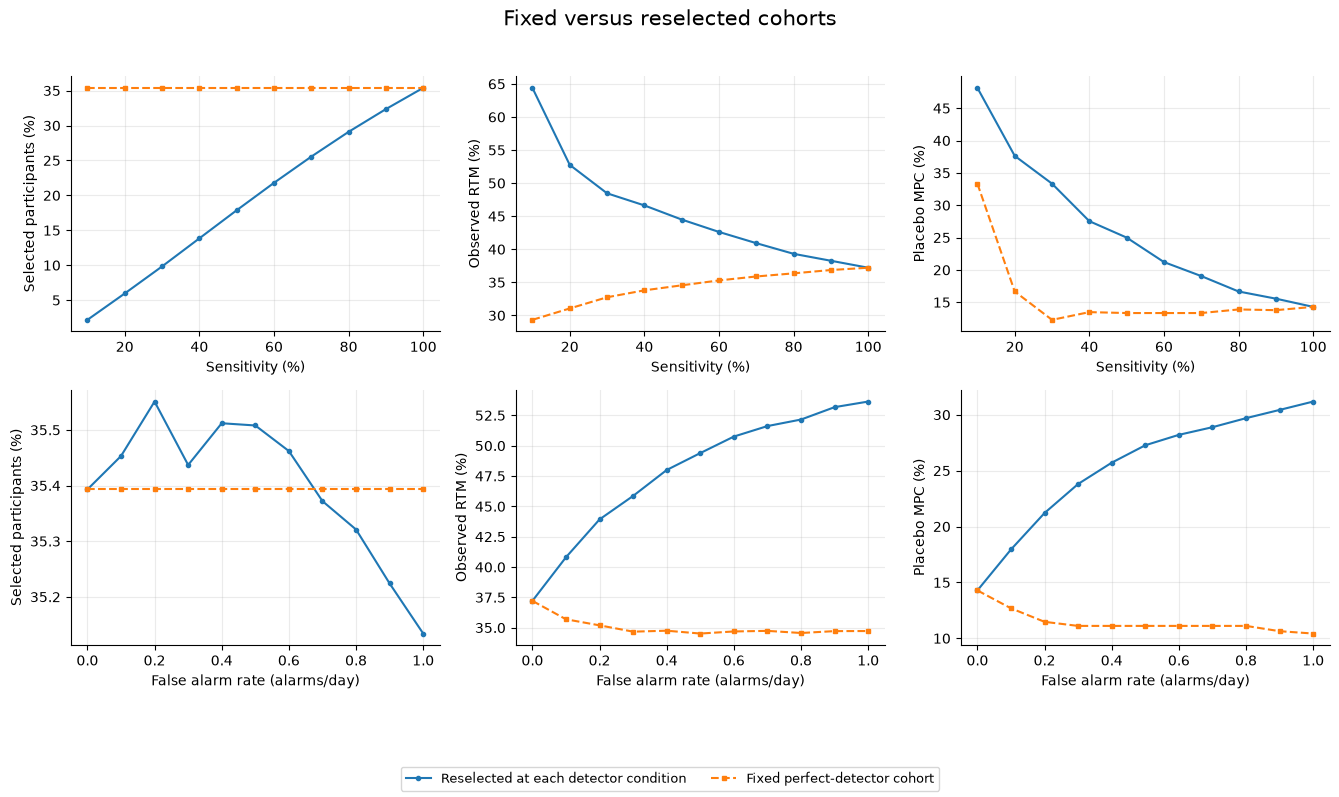

In [4]:
show_outcomes(results['cohort'], 'cohort_strategy')
comparison_figure(results['cohort'], 'cohort_strategy', 'Fixed versus reselected cohorts')
plt.show()

## Additive expected-alarm thresholds

Only eligibility uses raw counts. Outcomes retain monthly correction.

In [5]:
threshold_comparison(results)

,each_baseline_month_threshold_raw,mean_baseline_threshold_raw,baseline_total_threshold_raw,n_eligibility_mask_disagreements
FAR,,,,
0.000000,3.0,4.0,8.0,0
0.100000,6.0,7.0,14.0,0
0.200000,9.0,10.0,20.0,0
0.300000,12.0,13.0,26.0,0
0.400000,15.0,16.0,32.0,0
0.500000,18.0,19.0,38.0,0
0.600000,21.0,22.0,44.0,0
0.700000,24.0,25.0,50.0,0
0.800000,27.0,28.0,56.0,0


### Primary corrected-count eligibility

Condition,Selected n,Selected %,Observed RTM %,MPC %,MPC 95% CI,MPC denominator,Zero baseline n
FAR 0.0/day,35393,35.39,37.21,14.29,13.33 to 14.81,35393,0
FAR 0.1/day,35453,35.45,40.81,17.95,17.09 to 18.52,35453,0
FAR 0.2/day,35551,35.55,43.93,21.21,20.63 to 21.95,35551,0
FAR 0.3/day,35437,35.44,45.86,23.81,23.08 to 24.64,35437,0
FAR 0.4/day,35512,35.51,48.00,25.71,25.00 to 26.19,35512,0
FAR 0.5/day,35508,35.51,49.39,27.27,26.67 to 27.78,35508,0
FAR 0.6/day,35462,35.46,50.75,28.21,27.62 to 28.74,35462,0
FAR 0.7/day,35372,35.37,51.62,28.89,28.21 to 29.52,35372,0
FAR 0.8/day,35321,35.32,52.16,29.70,29.17 to 30.43,35321,0
FAR 0.9/day,35224,35.22,53.18,30.43,29.63 to 31.30,35224,0


### Raw counts with additive expected-alarm thresholds

Condition,Selected n,Selected %,Observed RTM %,MPC %,MPC 95% CI,MPC denominator,Zero baseline n
FAR 0.0/day,35393,35.39,37.21,14.29,13.33 to 14.81,35393,0
FAR 0.1/day,35453,35.45,40.81,17.95,17.09 to 18.52,35453,0
FAR 0.2/day,35551,35.55,43.93,21.21,20.63 to 21.95,35551,0
FAR 0.3/day,35437,35.44,45.86,23.81,23.08 to 24.64,35437,0
FAR 0.4/day,35512,35.51,48.00,25.71,25.00 to 26.19,35512,0
FAR 0.5/day,35508,35.51,49.39,27.27,26.67 to 27.78,35508,0
FAR 0.6/day,35462,35.46,50.75,28.21,27.62 to 28.74,35462,0
FAR 0.7/day,35372,35.37,51.62,28.89,28.21 to 29.52,35372,0
FAR 0.8/day,35321,35.32,52.16,29.70,29.17 to 30.43,35321,0
FAR 0.9/day,35224,35.22,53.18,30.43,29.63 to 31.30,35224,0


Across all 11 false-alarm conditions, additive raw-count thresholds selected exactly the same participants as corrected-count eligibility. All observed-RTM counts, median changes, and confidence limits were identical. This changes the expression of the rule, not its statistical precision. Outcome counts remain corrected in both analyses.

## The 25-day rule

Differences are sensitivity analysis minus main analysis, in percentage points.

### Original 25-day rule retained

Condition,Selected n,Selected %,Observed RTM %,MPC %,MPC 95% CI,MPC denominator,Zero baseline n
Sensitivity 10%,1692,1.69,65.78,48.15,45.83 to 50.00,1692,0
Sensitivity 20%,4838,4.84,54.75,38.89,37.50 to 40.00,4838,0
Sensitivity 30%,8274,8.27,50.95,33.33,33.33 to 33.33,8274,0
Sensitivity 40%,12057,12.06,48.85,29.82,28.21 to 31.82,12057,0
Sensitivity 50%,15875,15.88,46.53,26.67,25.93 to 27.27,15875,0
Sensitivity 60%,19673,19.67,44.45,23.08,22.22 to 24.14,19673,0
Sensitivity 70%,23348,23.35,42.55,20.00,20.00 to 21.21,23348,0
Sensitivity 80%,26836,26.84,40.68,18.23,17.46 to 18.52,26836,0
Sensitivity 90%,30094,30.09,39.40,16.67,16.13 to 16.67,30094,0
Sensitivity 100%,33109,33.11,38.17,15.15,14.29 to 15.65,33109,0


### 25-day rule on observed days

Condition,Selected n,Selected %,Observed RTM %,MPC %,MPC 95% CI,MPC denominator,Zero baseline n
FAR 0.0/day,33109,33.11,38.17,15.15,14.29 to 15.65,33109,0
FAR 0.1/day,35293,35.29,40.92,17.95,17.33 to 18.52,35293,0
FAR 0.2/day,35544,35.54,43.93,21.21,20.63 to 21.95,35544,0
FAR 0.3/day,35436,35.44,45.86,23.81,23.08 to 24.64,35436,0
FAR 0.4/day,35512,35.51,48.00,25.71,25.00 to 26.19,35512,0
FAR 0.5/day,35508,35.51,49.39,27.27,26.67 to 27.78,35508,0
FAR 0.6/day,35462,35.46,50.75,28.21,27.62 to 28.74,35462,0
FAR 0.7/day,35372,35.37,51.62,28.89,28.21 to 29.52,35372,0
FAR 0.8/day,35321,35.32,52.16,29.70,29.17 to 30.43,35321,0
FAR 0.9/day,35224,35.22,53.18,30.43,29.63 to 31.30,35224,0


### 25-day rule on latent true days

Condition,Selected n,Selected %,Observed RTM %,MPC %,MPC 95% CI,MPC denominator,Zero baseline n
FAR 0.0/day,33109,33.11,38.17,15.15,14.29 to 15.65,33109,0
FAR 0.1/day,31981,31.98,40.76,17.95,17.32 to 18.52,31981,0
FAR 0.2/day,30973,30.97,42.62,20.00,19.38 to 20.83,30973,0
FAR 0.3/day,30064,30.06,43.51,21.21,20.83 to 22.22,30064,0
FAR 0.4/day,29468,29.47,45.16,23.08,22.22 to 23.81,29468,0
FAR 0.5/day,28909,28.91,45.87,23.96,23.33 to 24.79,28909,0
FAR 0.6/day,28446,28.45,46.83,25.00,24.00 to 25.49,28446,0
FAR 0.7/day,28005,28.01,47.56,25.49,24.64 to 25.93,28005,0
FAR 0.8/day,27690,27.69,47.74,25.93,25.33 to 26.67,27690,0
FAR 0.9/day,27287,27.29,48.59,26.32,25.64 to 27.08,27287,0


Condition,"Selection difference, pp","Observed RTM difference, pp","MPC difference, pp"
Sensitivity 10%,-0.488,1.376,0.000
Sensitivity 20%,-1.117,1.992,1.254
Sensitivity 30%,-1.550,2.492,0.000
Sensitivity 40%,-1.788,2.221,2.288
Sensitivity 50%,-1.990,2.037,1.667
Sensitivity 60%,-2.117,1.831,1.865
Sensitivity 70%,-2.198,1.625,0.952
Sensitivity 80%,-2.257,1.365,1.564
Sensitivity 90%,-2.256,1.140,1.111
Sensitivity 100%,-2.284,0.957,0.866


Metric,"Maximum absolute difference, pp"
"Selection difference, pp",2.284
"Observed RTM difference, pp",2.492
"MPC difference, pp",2.288


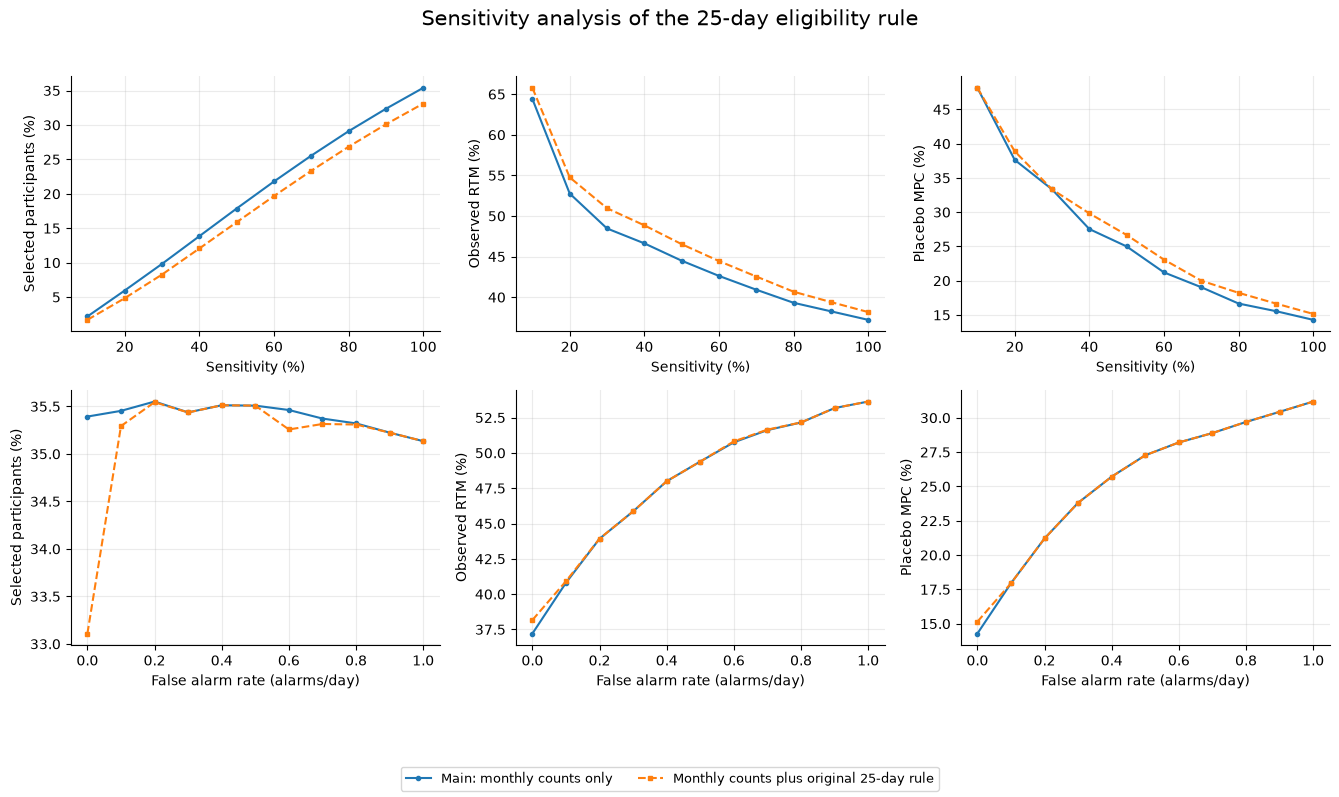

In [6]:
show_outcomes(results['interval'], 'eligibility_variant')
interval_comparison(results)
plt.show()

## Correction and interval alternatives

The raw-outcome comparison includes expected alarms in its reference. Oracle removal uses simulated alarm identities.

### Expected monthly correction; 25-day rule omitted

Condition,Selected n,Selected %,Observed RTM %,MPC %,MPC 95% CI,MPC denominator,Zero baseline n
FAR 0.0/day,35393,35.39,37.21,14.29,13.33 to 14.81,35393,0
FAR 0.1/day,35453,35.45,40.81,17.95,17.09 to 18.52,35453,0
FAR 0.2/day,35551,35.55,43.93,21.21,20.63 to 21.95,35551,0
FAR 0.3/day,35437,35.44,45.86,23.81,23.08 to 24.64,35437,0
FAR 0.4/day,35512,35.51,48.00,25.71,25.00 to 26.19,35512,0
FAR 0.5/day,35508,35.51,49.39,27.27,26.67 to 27.78,35508,0
FAR 0.6/day,35462,35.46,50.75,28.21,27.62 to 28.74,35462,0
FAR 0.7/day,35372,35.37,51.62,28.89,28.21 to 29.52,35372,0
FAR 0.8/day,35321,35.32,52.16,29.70,29.17 to 30.43,35321,0
FAR 0.9/day,35224,35.22,53.18,30.43,29.63 to 31.30,35224,0


### Expected monthly correction + original daily rounding

Condition,Selected n,Selected %,Observed RTM %,MPC %,MPC 95% CI,MPC denominator,Zero baseline n
FAR 0.0/day,33109,33.11,38.17,15.15,14.29 to 15.65,33109,0
FAR 0.1/day,35293,35.29,40.92,17.95,17.33 to 18.52,35293,0
FAR 0.2/day,35544,35.54,43.93,21.21,20.63 to 21.95,35544,0
FAR 0.3/day,35436,35.44,45.86,23.81,23.08 to 24.64,35436,0
FAR 0.4/day,35512,35.51,48.00,25.71,25.00 to 26.19,35512,0
FAR 0.5/day,35508,35.51,49.39,27.27,26.67 to 27.78,35508,0
FAR 0.6/day,35257,35.26,50.82,28.21,27.78 to 28.89,35257,0
FAR 0.7/day,35315,35.32,51.65,28.89,28.25 to 29.56,35315,0
FAR 0.8/day,35309,35.31,52.16,29.70,29.17 to 30.43,35309,0
FAR 0.9/day,35224,35.22,53.18,30.43,29.63 to 31.30,35224,0


### Expected monthly correction + observed daily intervals

...

Condition,Selected n,Selected %,Observed RTM %,MPC %,MPC 95% CI,MPC denominator,Zero baseline n
FAR 0.0/day,33109,33.11,38.17,15.15,14.29 to 15.65,33109,0
FAR 0.1/day,31981,31.98,40.76,17.95,17.32 to 18.52,31981,0
FAR 0.2/day,30973,30.97,42.62,20.00,19.38 to 20.83,30973,0
FAR 0.3/day,30064,30.06,43.51,21.21,20.83 to 22.22,30064,0
FAR 0.4/day,29468,29.47,45.16,23.08,22.22 to 23.81,29468,0
FAR 0.5/day,28909,28.91,45.87,23.96,23.33 to 24.79,28909,0
FAR 0.6/day,28446,28.45,46.83,25.00,24.00 to 25.49,28446,0
FAR 0.7/day,28005,28.01,47.56,25.49,24.64 to 25.93,28005,0
FAR 0.8/day,27690,27.69,47.74,25.93,25.33 to 26.67,27690,0
FAR 0.9/day,27287,27.29,48.59,26.32,25.64 to 27.08,27287,0


### Uncorrected observed counts; 25-day rule omitted

Condition,Selected n,Selected %,Observed RTM %,MPC %,MPC 95% CI,MPC denominator,Zero baseline n
FAR 0.0/day,35393,35.39,37.21,14.29,13.33 to 14.81,35393,0
FAR 0.1/day,71017,71.02,34.48,8.33,8.33 to 9.09,71017,0
FAR 0.2/day,95741,95.74,27.55,1.15,0.00 to 1.59,95741,0
FAR 0.3/day,99667,99.67,26.62,0.00,0.00 to 0.00,99667,0
FAR 0.4/day,99976,99.98,26.77,0.00,0.00 to 0.00,99976,0
FAR 0.5/day,99998,100.00,26.69,0.00,-0.68 to 0.00,99998,0
FAR 0.6/day,100000,100.00,26.83,0.00,0.00 to 0.00,100000,0
FAR 0.7/day,100000,100.00,26.94,0.00,-0.55 to 0.00,100000,0
FAR 0.8/day,100000,100.00,26.98,0.00,-0.50 to 0.00,100000,0
FAR 0.9/day,100000,100.00,27.10,0.00,-0.47 to 0.00,100000,0


### Exact oracle false-alarm removal

Condition,Selected n,Selected %,Observed RTM %,MPC %,MPC 95% CI,MPC denominator,Zero baseline n
FAR 0.0/day,35393,35.39,37.21,14.29,13.33 to 14.81,35393,0
FAR 0.1/day,35393,35.39,37.21,14.29,13.33 to 14.81,35393,0
FAR 0.2/day,35393,35.39,37.21,14.29,13.33 to 14.81,35393,0
FAR 0.3/day,35393,35.39,37.21,14.29,13.33 to 14.81,35393,0
FAR 0.4/day,35393,35.39,37.21,14.29,13.33 to 14.81,35393,0
FAR 0.5/day,35393,35.39,37.21,14.29,13.33 to 14.81,35393,0
FAR 0.6/day,35393,35.39,37.21,14.29,13.33 to 14.81,35393,0
FAR 0.7/day,35393,35.39,37.21,14.29,13.33 to 14.81,35393,0
FAR 0.8/day,35393,35.39,37.21,14.29,13.33 to 14.81,35393,0
FAR 0.9/day,35393,35.39,37.21,14.29,13.33 to 14.81,35393,0


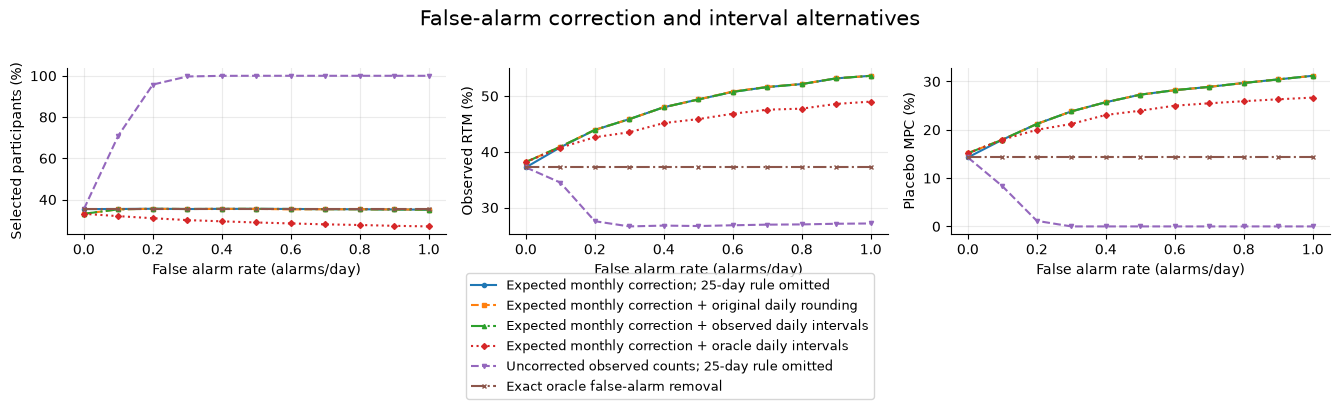

In [7]:
show_outcomes(results['correction'], 'correction_strategy')
comparison_figure(results['correction'], 'correction_strategy', 'False-alarm correction and interval alternatives')
plt.show()

## Interpretation

In [8]:
summarize_results(results)

With perfect detection, 35,393 of 100,000 participants were selected, observed RTM was 37.2%, and placebo median percentage change was 14.3%. Under reselection, the corresponding observed-RTM and median-change estimates were 64.4% and 48.1% at 10% sensitivity, and 53.6% and 31.2% at one false alarm/day.

Holding the perfect-detector cohort fixed gave observed RTM of 29.3% and median change of 33.3% at 10% sensitivity, and 34.7% and 10.4% at one false alarm/day. Median change was defined for 29,211 and 34,855 selected participants, respectively; 6,182 and 538 had zero measured baseline. These comparisons describe the influence of allowing cohort membership to change. They are not additive causal components of RTM, and the fixed-cohort median has a performance-dependent valid-baseline denominator.

Moving expected false alarms from the counts to the eligibility thresholds produced exactly identical results. It does not reduce the remaining random false-alarm error.

Retaining the original 25-day rule changed selection by at most 2.28 percentage points, observed RTM by 2.49 points, and MPC by 2.29 points. The main directions remained. Alternative interval rules gave different results because observed alarms and oracle seizure labels define different zero-day runs. Compared with the main analysis, the observed-day rule changed observed RTM and MPC less than the original rule did; the oracle-day rule changed them more. These comparisons concern the largest absolute differences across the sweep, not a uniform ordering at every condition.

Without any count correction or threshold adjustment, FAR one/day selected 100,000 participants, observed RTM was 27.1%, and MPC was 0.0%. This does not establish that uncorrected counts are preferable: alarms allow low-seizure-rate participants to pass fixed raw thresholds and contribute to both the baseline denominator and test counts. The reference now includes expected alarms so that the RTM comparison stays on the observation scale. Exact oracle removal retains the perfect-detector results at every FAR because it removes all realized simulated alarms. It is a diagnostic, not an available correction for unlabeled clinical events.

## Reproducibility checks

In [9]:
validate_artifacts(results)

{'MPC_denominators_complete': True,
 'additive_raw_thresholds_equivalent_to_primary': True,
 'exact_oracle_invariant_across_FAR': True,
 'fixed_and_reselected_perfect_detector_match': True,
 'fixed_cohort_size_invariant': True,
 'max_absolute_MPC_difference_primary_vs_original_25day_pp': 2.288329519450791,
 'max_absolute_eligibility_difference_primary_vs_original_25day_pp': 2.2840000000000025,
 'max_absolute_observed_RTM_difference_primary_vs_original_25day_pp': 2.491850280183833,
 'perfect_detector_condition_identical_between_sweeps': True,
 'primary_rows': 21,
 'status': 'PASS'}

PASS: the current analysis and simulator files match the recorded source hashes. All 21 primary conditions use the recorded cohort size.